# Mapeamento para turtlesim


Nesta etapa, são importadas as bibliotecas utilizadas no segundo pipeline do projeto, responsável pela integração entre os contornos extraídos e o ambiente ROS 2/turtlesim.

As bibliotecas json e Path são utilizadas para carregar os arquivos exportados pelo pipeline de visão computacional. Já NumPy e Matplotlib são empregados no processamento numérico e na visualização das trajetórias.

Todo o processamento geométrico deste notebook é realizado com lógica própria e operações matriciais, mantendo consistência com a proposta de implementação do projeto.


In [192]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


Nesta etapa, são definidos os caminhos dos arquivos utilizados pelo segundo pipeline do projeto. Os artefatos exportados pelo notebook de visão computacional, como bordas detectadas, máscaras de componentes e contornos rastreados, são carregados a partir da pasta results.

Também é definido o arquivo JSON responsável por armazenar os waypoints que serão utilizados posteriormente no controle da tartaruga no turtlesim.

Além disso, foi criada uma configuração para selecionar o modo de utilização da trajetória. Quando ativado, o sistema utiliza apenas o contorno principal da imagem, produzindo trajetórias mais simples e estáveis para navegação no ambiente ROS 2.

In [193]:
PROJECT_ROOT = Path('.').resolve()
RESULTS_DIR = PROJECT_ROOT / 'results'

# Artefatos exportados pelo pipeline_visao.ipynb
VISAO_EDGES_NPY = RESULTS_DIR / 'visao_edges_thresh39.npy'
VISAO_COMPONENT_NPY = RESULTS_DIR / 'visao_component_mask.npy'
VISAO_CONTOURS_NPZ = RESULTS_DIR / 'visao_contours_tracing.npz'

WAYPOINTS_JSON = RESULTS_DIR / 'turtlesim_waypoints.json'

# Configuração para usar apenas o contorno principal (maior area) ou todos os contornos detectados
USE_ONLY_MAIN_OUTLINE = True

# Converte borda espessa em linha central (single stroke), reduzindo contorno duplo
USE_CENTERLINE_FROM_MASK = False

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Modo contorno principal:', USE_ONLY_MAIN_OUTLINE)
print('Modo linha central (anti-duplo):', USE_CENTERLINE_FROM_MASK)




Modo contorno principal: True
Modo linha central (anti-duplo): False


Nesta etapa, foi implementada a função responsável por carregar os artefatos exportados pelo pipeline de visão computacional. O algoritmo verifica inicialmente se os arquivos necessários existem, garantindo que o processo de extração de contornos tenha sido executado corretamente antes da continuação do pipeline.

Em seguida, são carregadas as bordas detectadas, as máscaras de componentes e os contornos rastreados previamente salvos em arquivos NumPy. Cada contorno é convertido para o formato matricial adequado, permitindo seu uso nas próximas etapas de geração de trajetória.

Também é realizada a validação da existência de contornos válidos e a recuperação das dimensões originais da imagem, garantindo compatibilidade entre os dados carregados e o ambiente de navegação do turtlesim.

In [194]:
def load_visao_artifacts(edges_path: Path, component_path: Path, contours_path: Path):
    missing = [p for p in [edges_path, contours_path] if not p.exists()]
    if missing:
        missing_txt = '\n'.join(str(p) for p in missing)
        raise FileNotFoundError(
            'Artefatos do pipeline_visao nao encontrados.\n'
            'Execute a ultima celula de exportacao no pipeline_visao.ipynb e tente novamente.\n'
            f'Arquivos ausentes:\n{missing_txt}'
        )

    edges = np.load(edges_path).astype(np.uint8)

    component = None
    if component_path.exists():
        component = np.load(component_path).astype(np.uint8)

    data = np.load(contours_path, allow_pickle=True)
    contours_px = [np.array(c, dtype=np.int32) for c in data['contours']]

    if len(contours_px) == 0:
        raise RuntimeError('Nenhum contorno encontrado em visao_contours_tracing.npz')

    if 'image_shape' in data.files:
        image_shape = tuple(int(v) for v in data['image_shape'].tolist())
    else:
        image_shape = edges.shape

    return edges, component, contours_px, image_shape

Nesta etapa, os artefatos exportados pelo pipeline de visão computacional são carregados para o novo ambiente de processamento. As bordas detectadas, máscaras de componentes e trajetórias de contorno são recuperadas diretamente dos arquivos salvos anteriormente.

In [195]:
edges, component, contours_px, image_shape = load_visao_artifacts(
    VISAO_EDGES_NPY,
    VISAO_COMPONENT_NPY,
    VISAO_CONTOURS_NPZ,
)

print('Contornos carregados do pipeline_visao:', len(contours_px))

Contornos carregados do pipeline_visao: 1


Nesta etapa, fazemos o tratamento final dos contornos antes da geracao dos waypoints.

Quando `USE_CENTERLINE_FROM_MASK = True`, a mascara de bordas e afinada por esqueletizacao (algoritmo de Zhang-Suen implementado com NumPy), convertendo bordas espessas em trilhas de 1 pixel. Em seguida, essas trilhas sao percorridas e convertidas em caminhos continuos.

Esse modo reduz fortemente o efeito de borda dupla (duas linhas paralelas muito proximas). Caso necessario, tambem existe o modo de deduplicacao geometrica entre contornos proximos.

Por fim, quando `USE_ONLY_MAIN_OUTLINE = True`, apenas a trilha principal e mantida para um desenho mais estavel no turtlesim.



In [196]:
def _polygon_area_rc(contour_rc: np.ndarray) -> float:
    if len(contour_rc) < 3:
        return 0.0
    x = contour_rc[:, 1].astype(np.float64)
    y = contour_rc[:, 0].astype(np.float64)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def _bbox_xy(contour_rc: np.ndarray) -> tuple:
    ys = contour_rc[:, 0]
    xs = contour_rc[:, 1]
    x0, x1 = float(xs.min()), float(xs.max())
    y0, y1 = float(ys.min()), float(ys.max())
    return (x0, y0, x1, y1)


def _bbox_iou(a: tuple, b: tuple) -> float:
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b

    ix0, iy0 = max(ax0, bx0), max(ay0, by0)
    ix1, iy1 = min(ax1, bx1), min(ay1, by1)
    iw = max(0.0, ix1 - ix0)
    ih = max(0.0, iy1 - iy0)
    inter = iw * ih

    aa = max(0.0, ax1 - ax0) * max(0.0, ay1 - ay0)
    ba = max(0.0, bx1 - bx0) * max(0.0, by1 - by0)
    union = aa + ba - inter

    return inter / union if union > 0 else 0.0


def _point_in_polygon(x: float, y: float, poly_xy: np.ndarray) -> bool:
    inside = False
    n = len(poly_xy)
    if n < 3:
        return False

    x1, y1 = poly_xy[0]
    for i in range(1, n + 1):
        x2, y2 = poly_xy[i % n]
        if (y1 > y) != (y2 > y):
            xin = x1 + (x2 - x1) * (y - y1) / (y2 - y1 + 1e-12)
            if x < xin:
                inside = not inside
        x1, y1 = x2, y2

    return inside


def _point_segment_dist(px, py, ax, ay, bx, by) -> float:
    vx, vy = bx - ax, by - ay
    wx, wy = px - ax, py - ay
    vv = vx * vx + vy * vy
    if vv <= 1e-12:
        return float(((px - ax) ** 2 + (py - ay) ** 2) ** 0.5)
    t = max(0.0, min(1.0, (wx * vx + wy * vy) / vv))
    cx, cy = ax + t * vx, ay + t * vy
    return float(((px - cx) ** 2 + (py - cy) ** 2) ** 0.5)


def _point_polyline_dist(px: float, py: float, poly_xy: np.ndarray) -> float:
    n = len(poly_xy)
    if n == 0:
        return 1e9
    if n == 1:
        x, y = poly_xy[0]
        return float(((px - x) ** 2 + (py - y) ** 2) ** 0.5)

    best = 1e9
    for i in range(n):
        ax, ay = poly_xy[i]
        bx, by = poly_xy[(i + 1) % n]
        d = _point_segment_dist(px, py, ax, ay, bx, by)
        if d < best:
            best = d
    return best


def remove_near_duplicate_contours(contours: list,
                                   area_ratio_min: float = 0.65,
                                   area_ratio_max: float = 1.00,
                                   iou_min: float = 0.55,
                                   max_median_gap_px: float = 5.0,
                                   inside_frac_min: float = 0.60,
                                   sample_cap: int = 260) -> list:
    n = len(contours)
    if n <= 1:
        return contours

    areas = [_polygon_area_rc(c) for c in contours]
    bboxes = [_bbox_xy(c) for c in contours]
    polys_xy = [np.stack([c[:, 1], c[:, 0]], axis=1).astype(np.float64) for c in contours]

    keep = np.ones(n, dtype=bool)
    order = sorted(range(n), key=lambda i: areas[i], reverse=True)

    for oi, i in enumerate(order):
        if not keep[i] or areas[i] < 12:
            continue

        outer_poly = polys_xy[i]

        for j in order[oi + 1:]:
            if not keep[j] or areas[j] < 8:
                continue

            ratio = areas[j] / max(areas[i], 1e-9)
            if ratio < area_ratio_min or ratio > area_ratio_max:
                continue

            if _bbox_iou(bboxes[i], bboxes[j]) < iou_min:
                continue

            inner_poly = polys_xy[j]
            if len(inner_poly) == 0:
                continue

            step = max(1, len(inner_poly) // sample_cap)
            sample = inner_poly[::step]

            inside = 0
            dabs = []
            for x, y in sample:
                if _point_in_polygon(float(x), float(y), outer_poly):
                    inside += 1
                dabs.append(_point_polyline_dist(float(x), float(y), outer_poly))

            inside_frac = inside / max(len(sample), 1)
            med_gap = float(np.median(np.array(dabs, dtype=np.float64))) if dabs else 999.0

            if inside_frac >= inside_frac_min and med_gap <= max_median_gap_px:
                keep[j] = False

    return [contours[k] for k in range(n) if keep[k]]


def _path_length(contour_rc: np.ndarray) -> float:
    if len(contour_rc) < 2:
        return 0.0
    p = contour_rc.astype(np.float64)
    d = p[1:] - p[:-1]
    return float(np.sum(np.sqrt(np.sum(d * d, axis=1))))


def _path_score(contour_rc: np.ndarray) -> float:
    # Para trilhas abertas (esqueleto), comprimento e melhor metrica que area.
    # Para curvas fechadas, area ainda ajuda a privilegiar o contorno externo.
    n = len(contour_rc)
    if n < 2:
        return 0.0

    plen = _path_length(contour_rc)
    end_dist = float(np.linalg.norm(contour_rc[0].astype(np.float64) - contour_rc[-1].astype(np.float64)))
    is_closed = (n >= 3) and (end_dist <= 1.5)

    if is_closed:
        area = _polygon_area_rc(contour_rc)
        return area + 0.25 * plen

    return plen


def keep_main_outline_only(contours: list) -> list:
    if not contours:
        return contours
    scores = [_path_score(c) for c in contours]
    idx = int(np.argmax(np.array(scores, dtype=np.float64)))
    return [contours[idx]]


def keep_largest_connected_path_group(paths: list,
                                      endpoint_join_px: float = 1.5) -> list:
    if not paths:
        return paths

    n = len(paths)
    parent = list(range(n))

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    # Une trilhas que compartilham algum pixel
    point_owner = {}
    endpoints = []

    for i, p in enumerate(paths):
        if len(p) == 0:
            continue

        endpoints.append((i, p[0]))
        endpoints.append((i, p[-1]))

        for r, c in p.tolist():
            key = (int(r), int(c))
            if key in point_owner:
                union(i, point_owner[key])
            else:
                point_owner[key] = i

    # Une tambem pontas muito proximas (pequenas lacunas da esqueletizacao)
    thr2 = float(endpoint_join_px) * float(endpoint_join_px)
    m = len(endpoints)
    for a in range(m):
        ia, pa = endpoints[a]
        for b in range(a + 1, m):
            ib, pb = endpoints[b]
            if ia == ib:
                continue
            dr = float(pa[0] - pb[0])
            dc = float(pa[1] - pb[1])
            if dr * dr + dc * dc <= thr2:
                union(ia, ib)

    groups = {}
    for i, p in enumerate(paths):
        g = find(i)
        if g not in groups:
            groups[g] = {'idx': [], 'score': 0.0}
        groups[g]['idx'].append(i)
        groups[g]['score'] += _path_length(p)

    best = max(groups.values(), key=lambda z: z['score'])
    idx_set = set(best['idx'])
    return [paths[i] for i in range(n) if i in idx_set]


def _contours_bbox_stats(contours: list) -> tuple:
    if not contours:
        return 0.0, 0.0, 0

    pts = np.vstack(contours).astype(np.int32)
    ys = pts[:, 0]
    xs = pts[:, 1]

    w = float(xs.max() - xs.min() + 1)
    h = float(ys.max() - ys.min() + 1)
    n = int(len(pts))
    return w, h, n


def zhang_suen_thinning(mask_u8: np.ndarray, max_iters: int = 200) -> np.ndarray:
    img = (mask_u8 > 0).astype(np.uint8)

    for _ in range(max_iters):
        changed = False

        p2 = np.roll(img, 1, axis=0)
        p3 = np.roll(np.roll(img, 1, axis=0), -1, axis=1)
        p4 = np.roll(img, -1, axis=1)
        p5 = np.roll(np.roll(img, -1, axis=0), -1, axis=1)
        p6 = np.roll(img, -1, axis=0)
        p7 = np.roll(np.roll(img, -1, axis=0), 1, axis=1)
        p8 = np.roll(img, 1, axis=1)
        p9 = np.roll(np.roll(img, 1, axis=0), 1, axis=1)

        b = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
        a = (
            ((p2 == 0) & (p3 == 1)).astype(np.uint8) +
            ((p3 == 0) & (p4 == 1)).astype(np.uint8) +
            ((p4 == 0) & (p5 == 1)).astype(np.uint8) +
            ((p5 == 0) & (p6 == 1)).astype(np.uint8) +
            ((p6 == 0) & (p7 == 1)).astype(np.uint8) +
            ((p7 == 0) & (p8 == 1)).astype(np.uint8) +
            ((p8 == 0) & (p9 == 1)).astype(np.uint8) +
            ((p9 == 0) & (p2 == 1)).astype(np.uint8)
        )

        m1 = (
            (img == 1) &
            (b >= 2) & (b <= 6) &
            (a == 1) &
            ((p2 * p4 * p6) == 0) &
            ((p4 * p6 * p8) == 0)
        )
        m1[[0, -1], :] = False
        m1[:, [0, -1]] = False

        if np.any(m1):
            img[m1] = 0
            changed = True

        p2 = np.roll(img, 1, axis=0)
        p3 = np.roll(np.roll(img, 1, axis=0), -1, axis=1)
        p4 = np.roll(img, -1, axis=1)
        p5 = np.roll(np.roll(img, -1, axis=0), -1, axis=1)
        p6 = np.roll(img, -1, axis=0)
        p7 = np.roll(np.roll(img, -1, axis=0), 1, axis=1)
        p8 = np.roll(img, 1, axis=1)
        p9 = np.roll(np.roll(img, 1, axis=0), 1, axis=1)

        b = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
        a = (
            ((p2 == 0) & (p3 == 1)).astype(np.uint8) +
            ((p3 == 0) & (p4 == 1)).astype(np.uint8) +
            ((p4 == 0) & (p5 == 1)).astype(np.uint8) +
            ((p5 == 0) & (p6 == 1)).astype(np.uint8) +
            ((p6 == 0) & (p7 == 1)).astype(np.uint8) +
            ((p7 == 0) & (p8 == 1)).astype(np.uint8) +
            ((p8 == 0) & (p9 == 1)).astype(np.uint8) +
            ((p9 == 0) & (p2 == 1)).astype(np.uint8)
        )

        m2 = (
            (img == 1) &
            (b >= 2) & (b <= 6) &
            (a == 1) &
            ((p2 * p4 * p8) == 0) &
            ((p2 * p6 * p8) == 0)
        )
        m2[[0, -1], :] = False
        m2[:, [0, -1]] = False

        if np.any(m2):
            img[m2] = 0
            changed = True

        if not changed:
            break

    return (img * 255).astype(np.uint8)


def _neighbors8(r: int, c: int, H: int, W: int):
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            rr = r + dr
            cc = c + dc
            if 0 <= rr < H and 0 <= cc < W:
                yield rr, cc


def skeleton_to_paths(skel_u8: np.ndarray, min_points: int = 8) -> list:
    pts = np.argwhere(skel_u8 > 0)
    if len(pts) == 0:
        return []

    H, W = skel_u8.shape
    points_set = set((int(r), int(c)) for r, c in pts.tolist())
    neigh = {}
    degree = {}

    for r, c in points_set:
        nbs = []
        for rr, cc in _neighbors8(r, c, H, W):
            if (rr, cc) in points_set:
                nbs.append((rr, cc))
        neigh[(r, c)] = nbs
        degree[(r, c)] = len(nbs)

    def edge_key(a, b):
        return (a, b) if a <= b else (b, a)

    visited = set()
    paths = []

    starts = [p for p in points_set if degree[p] != 2]
    for s in starts:
        for nb in neigh[s]:
            ek = edge_key(s, nb)
            if ek in visited:
                continue

            path = [s, nb]
            visited.add(ek)
            prev, cur = s, nb

            while degree[cur] == 2:
                n1, n2 = neigh[cur]
                nxt = n1 if n2 == prev else n2
                ek2 = edge_key(cur, nxt)
                if ek2 in visited:
                    break
                path.append(nxt)
                visited.add(ek2)
                prev, cur = cur, nxt

            if len(path) >= min_points:
                paths.append(np.array(path, dtype=np.int32))

    for p in points_set:
        for nb in neigh[p]:
            ek = edge_key(p, nb)
            if ek in visited:
                continue

            path = [p, nb]
            visited.add(ek)
            prev, cur = p, nb

            while True:
                nbs = neigh[cur]
                candidates = [x for x in nbs if x != prev]
                if not candidates:
                    break
                nxt = candidates[0]
                ek2 = edge_key(cur, nxt)
                if ek2 in visited:
                    break
                path.append(nxt)
                visited.add(ek2)
                prev, cur = cur, nxt
                if cur == p:
                    break

            if len(path) >= min_points:
                paths.append(np.array(path, dtype=np.int32))

    return paths


def extract_centerline_paths(mask_u8: np.ndarray, min_points: int = 8) -> tuple:
    skel = zhang_suen_thinning(mask_u8)
    paths = skeleton_to_paths(skel, min_points=min_points)
    return skel, paths


raw_contours_px = list(contours_px)
contours_before = len(raw_contours_px)
outline_mask = component if component is not None else edges

skeleton_preview = None
used_centerline = False
if USE_CENTERLINE_FROM_MASK:
    skeleton_preview, centerline_paths = extract_centerline_paths(outline_mask, min_points=8)

    raw_points = sum(len(c) for c in raw_contours_px)
    center_points = sum(len(c) for c in centerline_paths)
    max_center_len = max((len(c) for c in centerline_paths), default=0)

    centerline_ok = (
        len(centerline_paths) >= 1 and
        center_points >= max(80, int(0.10 * max(raw_points, 1))) and
        max_center_len >= 25
    )

    if centerline_ok:
        contours_px = centerline_paths
        used_centerline = True
    else:
        # Fallback: evita resultado degenerado (ex.: apenas um pequeno segmento)
        skeleton_preview = None
        contours_px = remove_near_duplicate_contours(raw_contours_px)
else:
    contours_px = remove_near_duplicate_contours(raw_contours_px)

contours_mid = len(contours_px)

if USE_ONLY_MAIN_OUTLINE:
    if used_centerline:
        # Para esqueleto, manter apenas a maior trilha derruba o desenho.
        # Em vez disso, mantemos o maior grupo conectado de trilhas.
        contours_px = keep_largest_connected_path_group(contours_px)
    else:
        contours_px = keep_main_outline_only(contours_px)

# Guarda anti-colapso: se o resultado final ficar muito menor que o contorno bruto,
# volta ao fluxo estavel (deduplicacao + contorno principal).
raw_w, raw_h, raw_n = _contours_bbox_stats(raw_contours_px)
cand_w, cand_h, cand_n = _contours_bbox_stats(contours_px)

degenerate = False
if raw_n > 0 and raw_w > 0 and raw_h > 0:
    degenerate = (
        cand_n < max(120, int(0.12 * raw_n)) or
        cand_w < 0.45 * raw_w or
        cand_h < 0.45 * raw_h
    )

if degenerate:
    skeleton_preview = None
    used_centerline = False
    contours_px = remove_near_duplicate_contours(raw_contours_px)
    if USE_ONLY_MAIN_OUTLINE:
        contours_px = keep_main_outline_only(contours_px)

contours_after = len(contours_px)

print('Usando contornos exportados do pipeline_visao.ipynb')
print('Modo centerline usado:', used_centerline)
print('BBox bruto (w,h):', round(raw_w, 1), round(raw_h, 1), '| pontos:', raw_n)
print('BBox final  (w,h):', round(cand_w, 1), round(cand_h, 1), '| pontos:', cand_n)
print('Contornos antes do filtro:', contours_before)
print('Contornos apos processamento:', contours_mid)
print('Contornos finais usados:', contours_after)
print('Pontos totais:', sum(len(c) for c in contours_px))







Usando contornos exportados do pipeline_visao.ipynb
Modo centerline usado: False
BBox bruto (w,h): 99.0 151.0 | pontos: 1419
BBox final  (w,h): 99.0 151.0 | pontos: 1419
Contornos antes do filtro: 1
Contornos apos processamento: 1
Contornos finais usados: 1
Pontos totais: 1419


Nesta etapa, visualizamos os contornos finais usados para gerar a trajetoria do turtlesim.

A imagem da esquerda mostra as bordas exportadas pelo pipeline de visao. A imagem da direita mostra o resultado efetivo apos o processamento (linha central por esqueletizacao ou deduplicacao), com as trilhas que serao mapeadas para coordenadas do turtlesim.

Essa comparacao facilita validar se o contorno final preservou o formato desejado sem criar linhas paralelas artificiais.



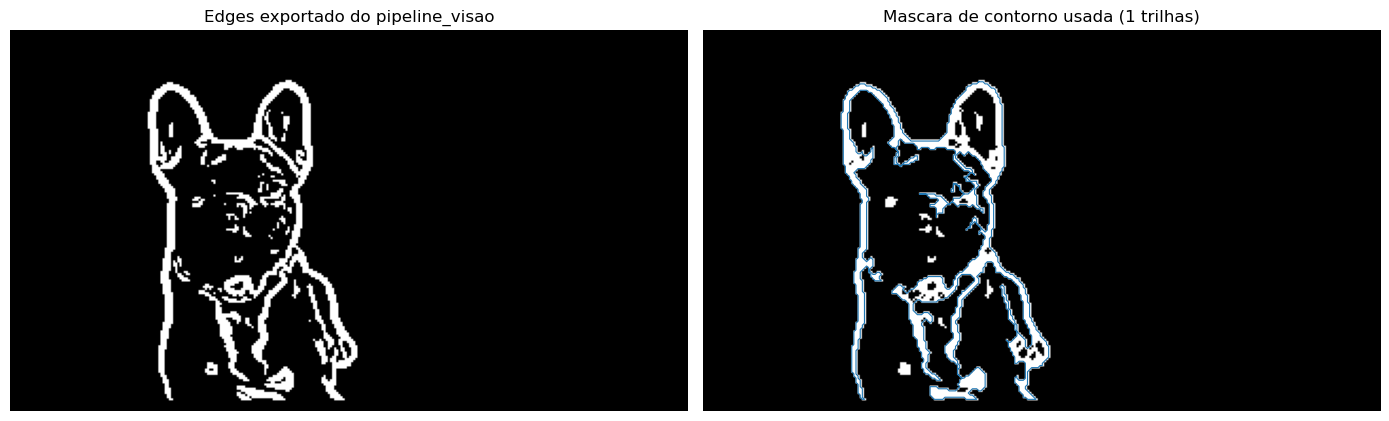

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(edges, cmap='gray')
axes[0].set_title('Edges exportado do pipeline_visao')
axes[0].axis('off')

if skeleton_preview is not None:
    preview = skeleton_preview
    preview_title = 'Linha central apos esqueletizacao'
else:
    preview = outline_mask if outline_mask is not None else (component if component is not None else edges)
    preview_title = 'Mascara de contorno usada'

axes[1].imshow(preview, cmap='gray')
for ct in contours_px:
    axes[1].plot(ct[:, 1], ct[:, 0], linewidth=0.8)
axes[1].set_title(f'{preview_title} ({len(contours_px)} trilhas)')
axes[1].axis('off')

plt.tight_layout()
plt.show()



Nesta etapa, os contornos em coordenadas de pixel são convertidos para o espaço do turtlesim. A função realiza um mapeamento isotrópico, ou seja, usa a mesma escala nos eixos X e Y para preservar a proporção original da imagem sem deformar o desenho.

Também é aplicada uma centralização automática dentro da área útil do turtlesim, limitada entre 0.5 e 10.5, evitando que a tartaruga desenhe muito próxima das bordas da janela.

Durante a conversão, o eixo Y é invertido, pois imagens usam a origem no canto superior esquerdo, enquanto o turtlesim trabalha com coordenadas cartesianas. Ao final, são geradas listas de pontos no formato adequado para serem usadas como waypoints no controle da tartaruga.

In [198]:
def map_contours_to_turtlesim(contours: list, image_shape: tuple,
                              x_min: float = 0.5, x_max: float = 10.5,
                              y_min: float = 0.5, y_max: float = 10.5,
                              stride: int = 1) -> list:
    
    # Mapeamento isotropico: preserva proporcao da imagem sem esticar
    H, W = image_shape
    out = []

    span_x = x_max - x_min
    span_y = y_max - y_min
    sx = span_x / max(W - 1, 1)
    sy = span_y / max(H - 1, 1)
    s = min(sx, sy)

    # Centraliza o desenho no espaco alvo
    used_x = s * max(W - 1, 1)
    used_y = s * max(H - 1, 1)
    x_off = x_min + (span_x - used_x) / 2.0
    y_off = y_min + (span_y - used_y) / 2.0

    for ct in contours:
        if stride > 1:
            ct = ct[::stride]

        pts = []
        last = None
        for r, c in ct:
            x = x_off + c * s
            y = y_off + (H - 1 - r) * s
            p = (float(x), float(y))

            if last is None or (abs(p[0] - last[0]) > 1e-9 or abs(p[1] - last[1]) > 1e-9):
                pts.append(p)
                last = p

        if len(pts) >= 2:
            out.append(pts)

    return out

contours_ts = map_contours_to_turtlesim(contours_px, image_shape, stride=1)
print('Contornos turtlesim:', len(contours_ts))
print('Pontos turtlesim:', sum(len(c) for c in contours_ts))



Contornos turtlesim: 1
Pontos turtlesim: 1419


Nesta etapa, é realizada a visualização final da trajetória já convertida para o sistema de coordenadas do turtlesim. Cada contorno é desenhado utilizando os pontos mapeados anteriormente, permitindo verificar se a geometria da imagem foi preservada após a transformação de escala e centralização.

O gráfico utiliza os mesmos limites espaciais do turtlesim (0 a 11) e mantém proporção fixa entre os eixos, garantindo uma representação fiel do movimento que será executado pela tartaruga no ambiente ROS 2.

Essa visualização funciona como uma etapa de validação antes da geração dos waypoints e do controle efetivo do robô.

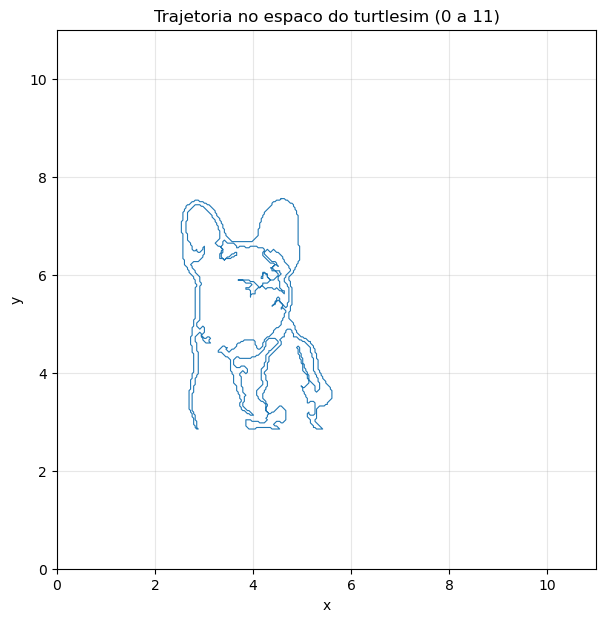

In [199]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for ct in contours_ts:
    xs = [p[0] for p in ct]
    ys = [p[1] for p in ct]
    ax.plot(xs, ys, linewidth=0.8)

ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Trajetoria no espaco do turtlesim (0 a 11)')
plt.show()


Nesta etapa, os contornos convertidos para o espaço do turtlesim são serializados em um arquivo JSON, formando a estrutura final de waypoints utilizada pelo sistema de navegação.

O arquivo armazena informações do sistema de coordenadas, limites do ambiente e a lista completa de trajetórias, onde cada ponto é representado por coordenadas (x, y) em formato compatível com o ROS 2.

Essa exportação permite desacoplar completamente o pipeline de visão computacional do sistema de controle robótico, facilitando o carregamento posterior das trajetórias pelo nó responsável por mover a tartaruga no turtlesim.

In [200]:
payload = {
    'frame': 'turtlesim_world',
    'bounds': {'x': [0.0, 11.0], 'y': [0.0, 11.0]},
    'contours': [
        [{'x': float(x), 'y': float(y)} for (x, y) in ct]
        for ct in contours_ts
    ]
}

WAYPOINTS_JSON.write_text(json.dumps(payload, indent=2), encoding='utf-8')
print('Waypoints salvos em:', WAYPOINTS_JSON)


Waypoints salvos em: C:\Users\Inteli\Documents\GitHub\pond-ros-visao\results\turtlesim_waypoints.json
